In [1]:
import numpy as np
import scipy.constants as const
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')

In [ ]:
def phuongphap_bisection(tol,p0,p1,N,filename,hamso):
    with open(f"{filename}_{hamso.__name__}_{tol}_bisection.txt", "w", encoding="utf-8") as file:
        file.write(f"# Giai phuong trinh f(x) = 0 bang phuong phap Bisection\n")
        file.write(f"# Do chinh xac cua phep tinh la: {tol}\n")
        file.write(f"#" * 100 + "\n")
        file.write(f"{"an":^10} {"bn": ^10} {"cn":^10} {"fn":^10}\n")
        i = 1
        if hamso(p0)*hamso(p1) > 0:
            file.write(f"Khong ton tai nghiem trong khoang [a,b]")
            return 
        for i in range(0,N):
            c = (p0+p1)/2
            file.write(f"{p0:<10.8f} {p1:<10.8f} {c:<10.8f} {hamso(c):<10.8e} \n")
            if hamso(c) == 0 or abs(p0 - p1) < tol:
                break
            else:
                if hamso(p0)*hamso(c) >0:
                    p0 = c
                else:
                    p1 = c
            if i == N - 1:
                file.write("!" * 70 + "\n" +"!" * 70 + "\n")
                file.write(f"'\n Khong tim duoc nghiem sau {N} vong lap'")

In [3]:
def print_thongso_gieng(a, V_0):
    z_0 = a * np.sqrt(V_0*0.0483)   # De cho 2m/hbar^2 = 0.0483 MeV^-1 fm^-2
    print(f"a = {a:.3f} fm")
    print(f"V_0 = {V_0:.3f} MeV")
    print(f"z_0 = {z_0:.8f}")

# TH1: hẹp & nông
V_MeV_hep_nong = 1.0
a_fm_hep_nong = 2

print("THE HEP & NONG")
print_thongso_gieng(a_fm_hep_nong, V_MeV_hep_nong)

print()

# TH2: rộng & sâu
V_MeV_rong_sau = 10.0
a_fm_rong_sau = 10.0

print("THE RONG & SAU")
print_thongso_gieng(a_fm_rong_sau, V_MeV_rong_sau)

THE HEP & NONG
a = 2.000 fm
V_0 = 1.000 MeV
z_0 = 0.43954522

THE RONG & SAU
a = 10.000 fm
V_0 = 10.000 MeV
z_0 = 6.94982014


In [4]:
def vehinh(z_0,N,title):
    z = np.linspace(0, 8, 10000)

    y1 = np.sqrt((z_0/z)**2 - 1)
    y2 = np.tan(z)

    y2[np.abs(y2) > 15] = np.nan

    plt.figure(figsize=(10, 6))

    plt.plot(z, y1, label=r'$\sqrt{(z_0/z)^2-1}$', color='C0')
    plt.plot(z, y2, label=r'$\tan z$', color='C1')

    x_ticks = np.arange(np.pi/2, 20 + np.pi/2, np.pi/2)

    x_labels = []
    for i in range(1, len(x_ticks) + 1):
        if i == 1:
            x_labels.append(r'$\frac{\pi}{2}$')
        else:
            x_labels.append(rf'$\frac{{{i}\pi}}{{2}}$')

    plt.xticks(x_ticks, x_labels)

    for xt in x_ticks:
        plt.axvline(xt, color='gray', lw=0.5, ls='--')

    plt.axhline(0, color='gray', lw=0.5, ls='--')

    #plt.axvline(3/8*np.pi, color='gray', lw=0.5, ls='--')

    #plt.axvline(0.9*np.pi/2, color='gray', lw=0.5, ls='--')

    #plt.axvline((2+1/16)*np.pi, color='red', lw=0.5, ls='--')

    #plt.axvline((2+1/8)*np.pi, color='red', lw=0.5, ls='--')

    plt.xlim(0, 10)

    x_lim = N * np.pi / 2
    plt.xlim(0, x_lim)
    plt.ylim(0, 10)
    plt.xlabel('z')
    plt.title(rf'$z_0={z_0:.8f}$'+f' - {title}')
    plt.legend()
    plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15616\1586281576.py:4: RuntimeWarning: divide by zero encountered in divide
  y1 = np.sqrt((z_0/z)**2 - 1)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15616\1586281576.py:4: RuntimeWarning: invalid value encountered in sqrt
  y1 = np.sqrt((z_0/z)**2 - 1)


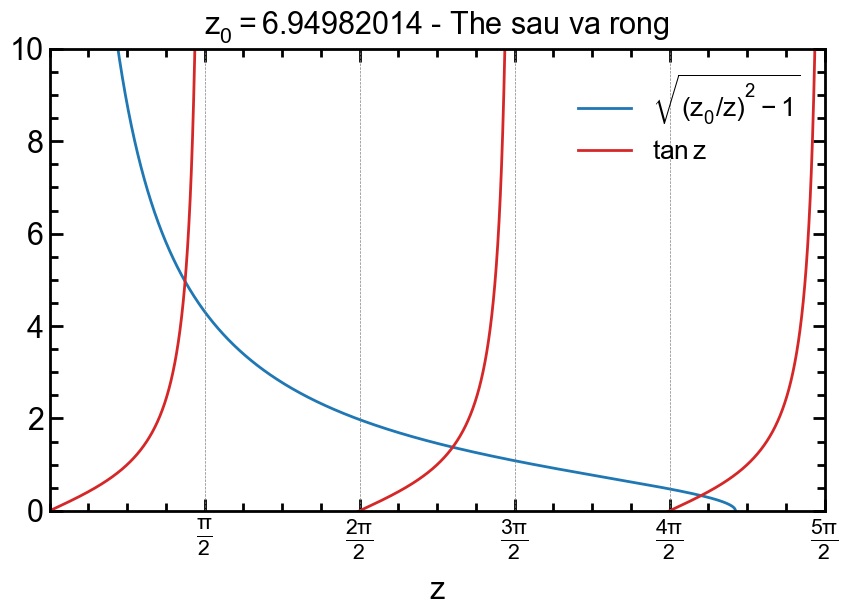

In [5]:
vehinh(6.94982014,5, 'The sau va rong')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15616\1586281576.py:4: RuntimeWarning: divide by zero encountered in divide
  y1 = np.sqrt((z_0/z)**2 - 1)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15616\1586281576.py:4: RuntimeWarning: invalid value encountered in sqrt
  y1 = np.sqrt((z_0/z)**2 - 1)


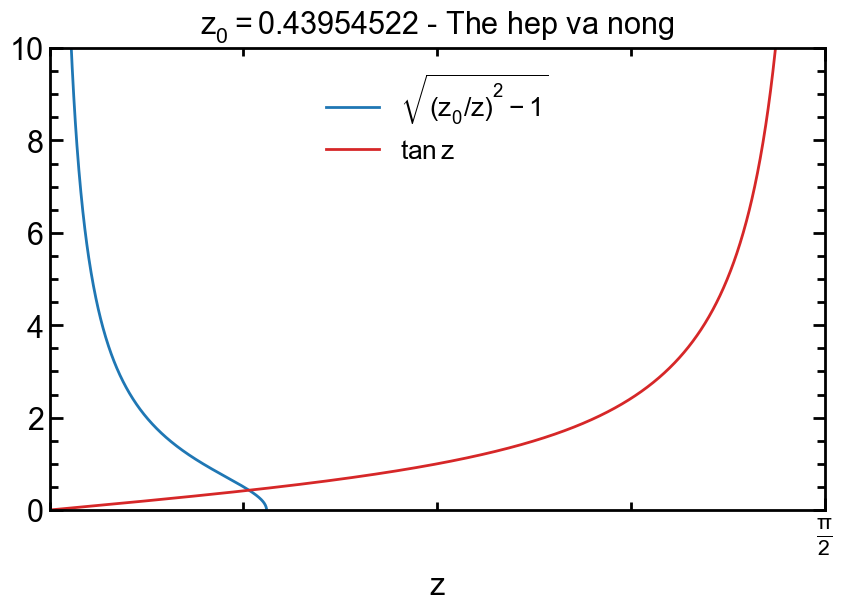

In [6]:
vehinh(0.43954522,1, 'The hep va nong')

In [7]:
def giengthehuuhan(a, V_0, z):
    z_0 = a * np.sqrt(V_0*0.0483)   # De cho 2m/hbar^2 = 0.0483 MeV^-1 fm^-2
    y1 = np.sqrt((z_0/z)**2 - 1)
    y2 = np.tan(z)
    pt_tim_z = y1 - y2
    return z_0, pt_tim_z

def tinh_z0(a, V0):
    z0 = a*np.sqrt(0.0483*V0)   
    return z0

def tao_khoang_bisection_tu_z0(z0):
    if z0 <= 0:
        return [], []
        
    f = lambda z: np.tan(z) - np.sqrt((z0/z)**2 - 1)
    
    delta = min(1e-5, z0 * 1e-4) 
    so_luong_nghiem_toi_da = int(z0 / np.pi) + 1
    
    p0_list = []
    p1_list = []
    
    for i in range(so_luong_nghiem_toi_da):
        a = i * np.pi + delta              
        
        b_candidate = (i + 0.5) * np.pi - delta
        b = min(b_candidate, z0)      
        
        with np.errstate(invalid='ignore'):
            if a < b and not np.isnan(f(a)) and not np.isnan(f(b)):
                if f(a) * f(b) <= 0:   
                    p0_list.append(a)
                    p1_list.append(b)
    return p0_list, p1_list

z0_sau_rong = tinh_z0(a_fm_rong_sau,V_MeV_rong_sau)
z0_nong_hep = tinh_z0(a_fm_hep_nong,V_MeV_hep_nong)
p0_sau_rong, p1_sau_rong = tao_khoang_bisection_tu_z0(z0_sau_rong)
p0_nong_hep, p1_nong_hep = tao_khoang_bisection_tu_z0(z0_nong_hep)


In [8]:
N = 100
tol = 1e-8

def hamso_secant_sau_rong(z):
    return giengthehuuhan(a_fm_rong_sau, V_MeV_rong_sau, z)[1]

def hamso_secant_nong_hep(z):
    return giengthehuuhan(a_fm_hep_nong, V_MeV_hep_nong, z)[1]

for i in range(len(p0_sau_rong)):
    phuongphap_bisection(tol, p0_sau_rong[i], p1_sau_rong[i], N, f'ketqua_sau_rong_nghiem_so_{i+1}', hamso_secant_sau_rong)

for i in range(len(p0_nong_hep)):
    phuongphap_bisection(tol, p0_nong_hep[i], p1_nong_hep[i], N, f'ketqua_nong_hep_nghiem_so_{i+1}', hamso_secant_nong_hep)

## Input nhu Thay dua ra
## V0 = 83 MeV
## a = 2 fm

In [9]:
V_MeV_Thayduara = 83
a_fm_Thayduara = 2

print("Tinh z0 ma Thay dua ra")
print_thongso_gieng(a_fm_Thayduara,V_MeV_Thayduara)

Tinh z0 ma Thay dua ra
a = 2.000 fm
V_0 = 83.000 MeV
z_0 = 4.00444753


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15616\1586281576.py:4: RuntimeWarning: divide by zero encountered in divide
  y1 = np.sqrt((z_0/z)**2 - 1)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15616\1586281576.py:4: RuntimeWarning: invalid value encountered in sqrt
  y1 = np.sqrt((z_0/z)**2 - 1)


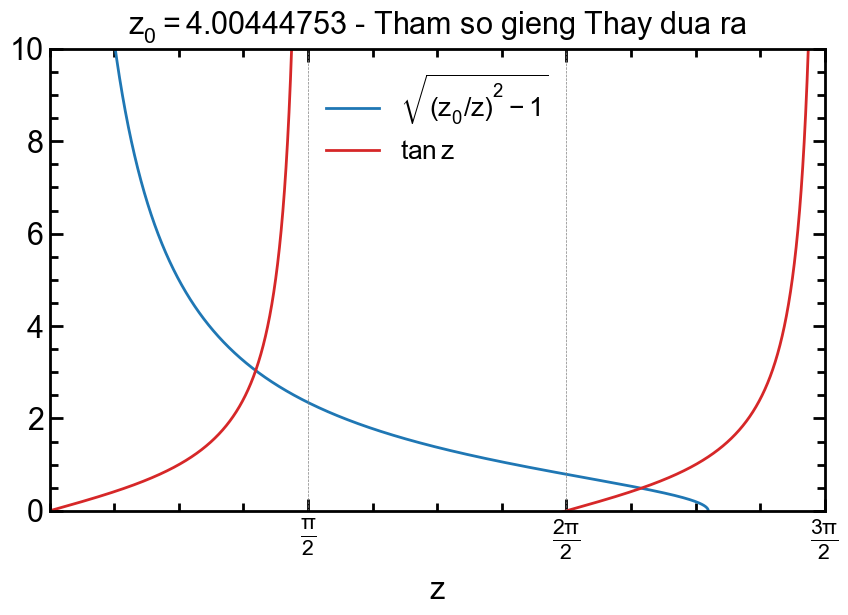

In [10]:
vehinh(4.00444753,3, 'Tham so gieng Thay dua ra')

In [11]:
p0_thayduara = [np.pi/4, np.pi/2+0.1*np.pi/2]
p1_thayduara = [0.9*np.pi/2, 5/4*np.pi]

def hamso_secant_Thay_dua_ra(z):
    return giengthehuuhan(a_fm_Thayduara, V_MeV_Thayduara, z)[1]

for i in range(len(p0_thayduara)):
    phuongphap_bisection(tol, p0_thayduara[i], p1_thayduara[i], N, f'ketqua_thayduara_nghiem_so_{i+1}', hamso_secant_Thay_dua_ra)